<font size = 8> Barnacle detenction using Image Processing. 

<font size=4> In this notebook, I explore a series of computer vision techniques to process the image. The process involves a sequence of steps including filtering, binarization, morphological transformations, and contour detection. Finally, I perform watershed algorithm on the image to effectively segment the clustered barnacles and find the total number present. 

This pipeline is demonstrated using one of the images provided for the challenge. While it can be applied to other images, a key disclaimer is necessary: this technique relies on traditional, rule-based image processing algorithms, rather than leveraging state-of-the-art deep learning models specifically trained for barnacle detection. Consequently, its effectiveness is highly dependent on the input image characteristics, and it may produce false positives on images that do not contain actual barnacles but share similar visual features. Specifically, this pipeline assumes that input images, such as those provided in the challenge, consist solely of barnacle-covered surfaces.

<font size = 5> Importing necessary libraries

In [565]:
import numpy as np
import cv2
from matplotlib import pyplot as plt 
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from PIL import Image
from helpers import *


In [566]:
THRESHOLD =0.27 #Optimal threshold decided based on a manual grid search across 20+ different values
image_path = "images/sample_image.png"

<font size= 5> Grayscaling the image and reducing noise</font>

<Font size = 4.5> Firstly, I grayscale the image. Grayscaling is important here because it reduces the pixel data from three color dimensions (e.g., RGB) to a single dimension of intensity. This significantly reduces the number of calculations that need to be performed by subsequent image processing operations. Moreover, converting single-dimension pixel values to binary values is much easier than doing so for multi-dimensional ones. Since binarization of the pixels is at the core of this pipeline, grayscaling becomes even more essential. 

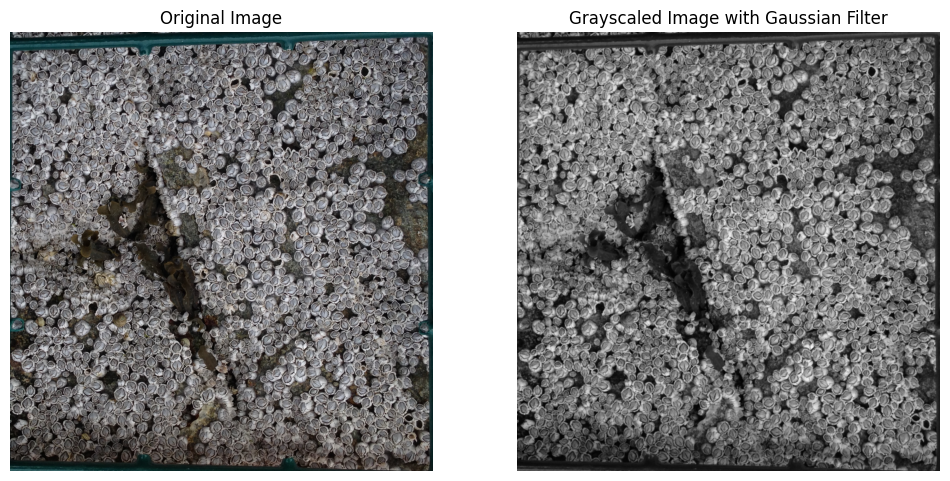

In [567]:
image = Image.open(image_path).convert("RGB")
grayscale_image = image.convert("L")
image_array = np.array(grayscale_image)
gaussian_filtered_image = gaussian_filter(image_array, sigma=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(gaussian_filtered_image, cmap= 'gray')
ax[1].set_title('Grayscaled Image with Gaussian Filter')
ax[1].axis('off')

plt.show()

<font size= 6> Applying Otsu's Thresholding</font>

<font size = 4>Otsu's method is a popular algorithm for automatic image thresholding. The 'optimal' threshold calculated using Otsu's method is then used to convert a grayscale image into a binary image.

It operates by iterating over every possible intensity threshold for binarization, and segmenting pixels into two classes (black and white). For each threshold, it calculates the variance within and between these classes. The algorithm then selects the threshold that lead to the the least intra-class variance (meaning the pixels within each class are as similar as possible). Essentially, I would say it functions  as a clustering algorithm.

As Otsu's method strives for low intra-class variance, it performs very well when there is a clear, bimodal distribution of pixel intensities in the image's histogram. Consequently, in situations with low contrast or images containing diverse object types, its performance may not be optimal. I utilize Otsu's method in this pipeline because, in the unseen images, the barnacles are quite well distinguished from the background, and there are no other 'noisy' objects to interfere with the binarization process.

Obtained threshold: 94.0


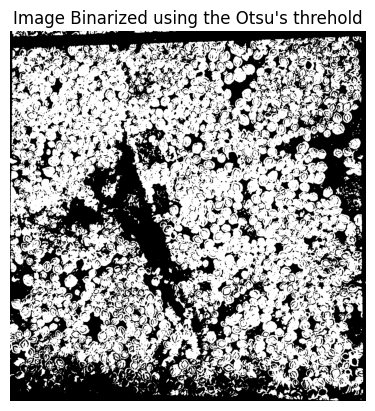

In [568]:
otsu_threshold, image_after_otsu = cv2.threshold(
gaussian_filtered_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU, 
)
print("Obtained threshold:", otsu_threshold)

plt.imshow(image_after_otsu, cmap= 'gray')
plt.title("Image Binarized using the Otsu's threhold")
plt.axis('off')
plt.show()


<font size =6> Removing Noise</font>

<font size = 4.2> In the code below, the 'kernel' is a small matrix that slides over the image. Its size determines the dimensions of the "neighborhood" of pixels that any morphological operation will consider for each pixel in the image. A larger kernel size generally results in a stronger effect from morphological transformations, such as eroding or dilating.

In images with more clustering and important fine-grained details, I found that using a smaller kernel size provided greater control over the transformation, helping to preserve subtle features. For images with less need for detail preservation or less dense clustering of barnacles, a larger kernel size might have a less noticeable impact, but it generally still applies a stronger transformation. Essentially, what size to choose depends on the type of image and how aggresively you want to perform an operation on the image. 

After setting the kernel size, I perform Opening, which is an erosion operation followed immediately by a dilation operation, using the same kernel. Erosion is used to shrink foreground (white) areas, effectively eliminating small noise pixels. Subsequently, dilation expands the remaining white areas back again. I perform this step as it helps remove small noisy areas that could otherwise be erroneously identified as barnacles.

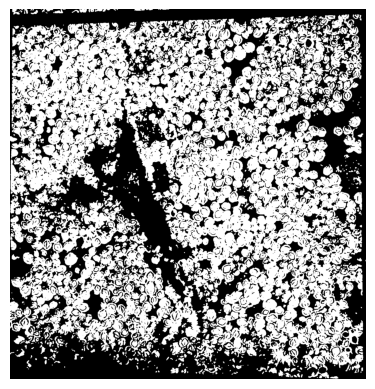

In [569]:
# noise removal
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

cleaned_image = cv2.morphologyEx(image_after_otsu, 
                           cv2.MORPH_OPEN,
                           kernel,
                           iterations=1)
plt.imshow(cleaned_image, cmap='gray')
plt.axis('off')
plt.show()

<font size=5> Morphological Transformations

<font size=4>This is a crucial pre-processing step for the Watershed algorithm, designed to clearly seperate the sure foreground (barnacles), sure background, and the unknown areas between them.

First, the sure background is established by aggressively dilating the cleaned, binary image with four iterations. This process expands foreground objects, ensuring that any areas remaining black after this  expansion can be confidently classified as background.

Next, a distance transform is applied. This operation calculates each white (foreground) pixel's distance to its nearest black (background) pixel and creates a grayscale map where brighter intensities highlight object cores The pixels deep within an object are pretty far from their boundaries.

Following this, the sure foreground is isolated by thresholding this distance map, specifically at THRESHOLD * dist.max(). This process extracts the unambiguous object cores. For barnacles with their slightly elliptical shape, a higher threshold ( 0.5) was pretty unsuitable as it risked excluding pixels even near the center of the objects. Through initial experimentation and a grid search, I found 0.27 optimally capture foreground seeds the best. While effective for objects with predictable shapes, this thresholding method may struggle with highly irregular ones.

Finally, the region remaining between the sure foreground and sure background is the unknown area. This ambiguous zone,  containing object boundaries or merging points, is where the Watershed algorithm will perform its segmentation.

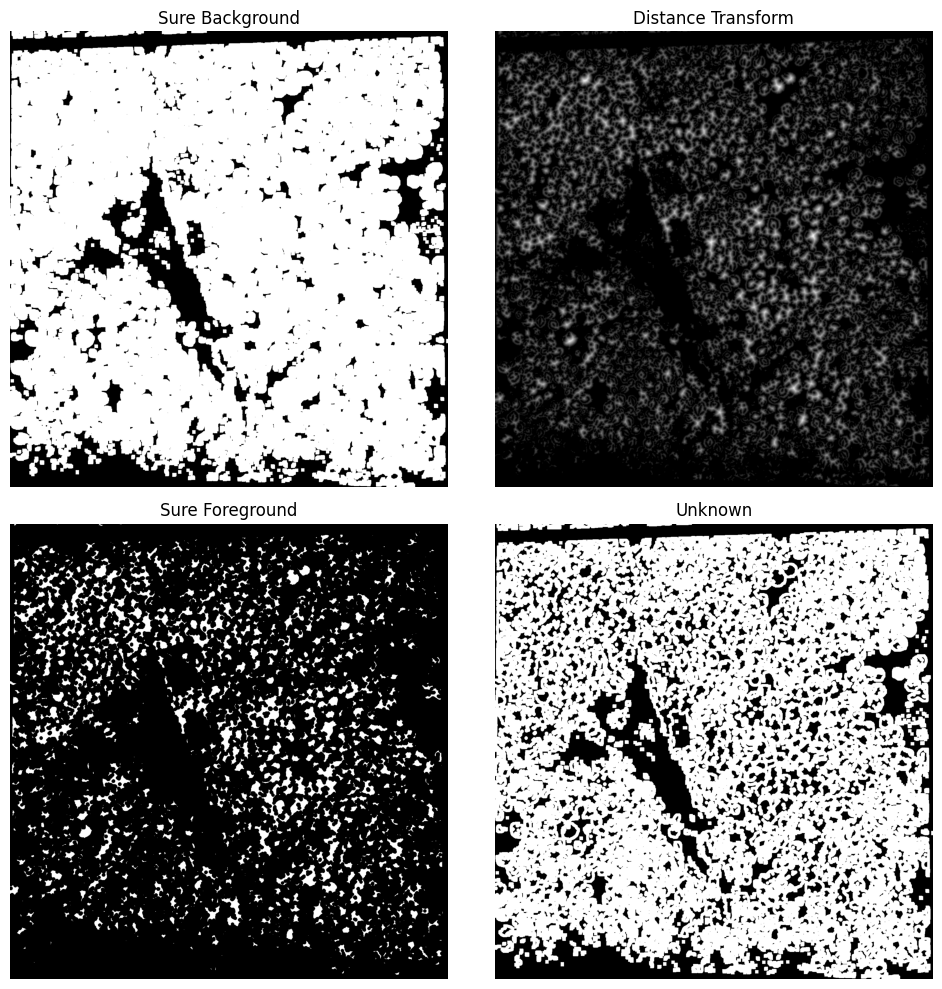

In [570]:
# Create subplots with 2 rows and 2 columns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

# sure background area
sure_bg = cv2.dilate(cleaned_image, kernel, iterations=4)
axes[0,0].imshow(sure_bg, cmap='gray') # Corrected line
axes[0, 0].set_title('Sure Background')
axes[0,0].axis("off")

# Distance transform
dist = cv2.distanceTransform(cleaned_image, cv2.DIST_L2,5)
axes[0,1].imshow(dist, cmap='gray') 
axes[0, 1].set_title('Distance Transform')
axes[0,1].axis("off")

# foreground area
ret, sure_fg = cv2.threshold(dist, THRESHOLD * dist.max(), 255, cv2.THRESH_BINARY)
sure_fg = sure_fg.astype(np.uint8)
axes[1,0].imshow(sure_fg, cmap='gray') 
axes[1, 0].set_title('Sure Foreground')
axes[1,0].axis("off")
# unknown area
unknown = cv2.subtract(sure_bg, sure_fg)
axes[1,1].imshow(unknown, cmap='gray') 
axes[1, 1].set_title('Unknown')
axes[1,1].axis("off")


plt.tight_layout()
plt.axis('off')
plt.show()

<font size = 5> Marker Labelling</font>


<font size=4.5>This is the final step before applying the Watershed algorithm. Here, the cv2.connectedComponents method identifies all distinct clusters or groups of connected white pixels in the sure_fg image and assigns each a unique integer ID. This operation is performed on the sure_fg (sure foreground) image, where each cluster of white pixels ideally represents a unique barnacle. Ideally, any barnacles that were originally connected should also have been separated on the sure_fg image by the preceding distance transform and thresholding steps. In the output of cv2.connectedComponents, background pixels are assigned a value of 0.


Following this, one is added to every cluster's ID, including the background. The background's ID shifts from 0 to 1. After this adjustment, a boolean mask is applied to the markers image. All pixels identified as part of the unknown region (where unknown == 255) are then assigned an ID of 0. This final markers image, containing unique positive IDs for sure foreground, a value of 1 for sure background, and 0 for the unknown areas, is precisely what the Watershed algorithm expects as input.

This is a pretty important step, at it basically distinguishes all the pixel clusters from each other as well as from the background and unknown regions. As you will read below, this is needed for the watershed algorithm to work

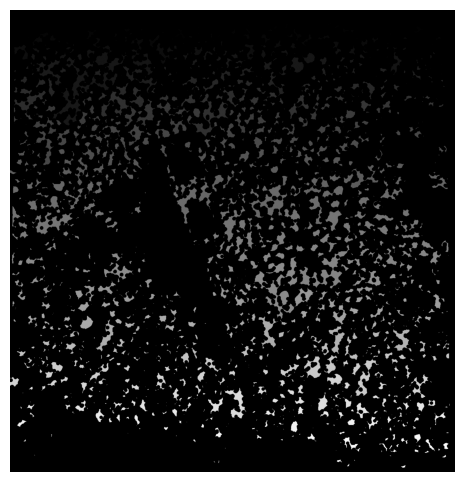

In [571]:
# Marker labelling
# sure foreground 
ret, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels so that background is not 0, but 1
markers += 1

# mark all the regions white pixels in the 'unknown' image with a value of zero. Essentially, we assigning a unique id 0 to all the unknown pixels. 
markers[unknown == 255] = 0

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(markers, cmap="gray")
ax.axis('off')
plt.show()

<font size =5> Applying Watershed Algorithm

 <font size  = 4> The Watershed Algorithm is a powerful image processing technique used for segmentation, particularly effective at separating touching or overlapping objects. Once the algorithm is applied, contours are drawn on the original image for better visualization of how the algorithm identifies individual objects (barnacles) within the image.

The Watershed algorithm operates by treating the input image's pixel intensities as a topographical map, where darker pixels represent valleys and brighter pixels represent ridges. The previously labeled regions (markers, which are ridges in this case) then iteratively grow outwards towards the unknown area (ID 0). This growth occurs towards pixels with lower intensities in the original image, similar  to water flowing downhill. As the markers continue to expand, an 'unknown' pixel is assigned to the marker that reaches it first. This expansion stops when pixels from two different markers touch, at which point a boundary (or "dam") is  formed. This boundary defines teh edges of the objects.

Once the Watershed algorithm completes its segmentation, a loop is executed to isolate pixels corresponding to each unique object label. For each isolated object, its contour (outline) is then extracted and drawn around that object or labeled cluster, providing a clear visual representation of the segmentation results on the original image.

Here, it is important to note that, similar to all the operations above, I perform the watershed algorithm on a filtered/ denoised version of the original image. This essentially helps remove any noise that might affect the intensities or the 'topography' of the image, which may affect the performance of the watershed algorithm. 


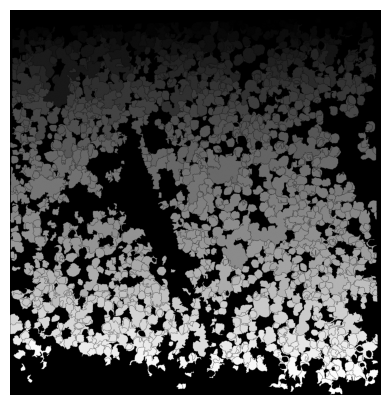

<function matplotlib.pyplot.show(close=None, block=None)>

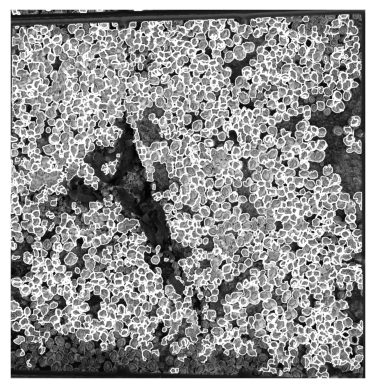

In [572]:
# watershed Algorithm
img_array = np.array(image).astype(np.uint8)
filtered_img = gaussian_filter(img_array, sigma = 1)
markers = cv2.watershed(filtered_img, markers)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(markers, cmap="gray")
ax.axis('off')
plt.show()


labels = np.unique(markers)

barnacles = []
for label in labels[2:]:  

# Create a binary image in which only the area of the label is in the foreground and the rest of the image is in the background   
    target = np.where(markers == label, 255, 0).astype(np.uint8)
  
  # Perform contour extraction on the created binary image
    contours, hierarchy = cv2.findContours(
        target, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    barnacles.append(contours[0])

# Draw the outline
image = cv2.drawContours(image_array, barnacles, -1, color=(255, 255, 255), thickness=2)
plt.axis("off")
plt.imshow(image, cmap ='grey')
plt.show

In [573]:
print(f"The number of barnacles is {len(barnacles)}")

The number of barnacles is 1475


<FONT SIZE =6> Calulating the actual number of Barnacles</font>

<font size = 4> To determine the actual number of barnacles from the provided ground truth mask images, I utilized Connected Component Labeling. The Watershed algorithm was not applied directly here as it relies on intensity information for segmentation, which these plain binary masks lack.

Connected Component Labeling is a robust technique that identifies and labels distinct, connected regions in binary images. This method is highly effective for counting individual instances when objects (or masks) are clearly separate and do not physically touch or overlap significantly. It's important to note that if objects are connected in the binary mask, this method will count them as a single entity.Below, I present a demonstration of how this works. 


In [574]:
image = cv2.imread("masks/mask1.png")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
thresh = cv2.threshold(gray, 0, 255,
	cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
connectivity= 8 

In [575]:
output = cv2.connectedComponentsWithStats(
	thresh, connectivity, cv2.CV_32S)
(numLabels, labels, stats, centroids) = output

In [576]:
all_components_output = image.copy()

for i in range(0, numLabels):
    
    if i == 0:
        text = "examining component {}/{} (background)".format(i + 1, numLabels)


    # extract the connected component statistics and centroid for the current label
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]
    (cX, cY) = centroids[i]

    # Draw on a temporary copy for showing individual component
    current_component_output = image.copy()
    cv2.rectangle(current_component_output, (x, y), (x + w, y + h), (0, 255, 0), 3) # Green rectangle
    cv2.circle(current_component_output, (int(cX), int(cY)), 4, (0, 0, 255), -1) # Red circle for centroid

    # Also draw on the cumulative output image
    if i > 0: # Don't draw background's bbox on cumulative image
        cv2.rectangle(all_components_output, (x, y), (x + w, y + h), (0, 255, 0), 2) # Thinner green rectangle
        cv2.circle(all_components_output, (int(cX), int(cY)), 3, (0, 0, 255), -1)

    componentMask = (labels == i).astype("uint8") * 255

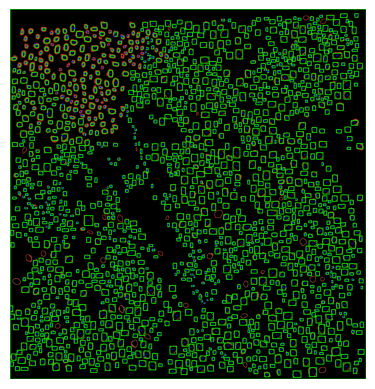

The actual number of Barnacles is 1745


In [577]:
all_components_output_array = np.array 
plt.imshow(all_components_output)
plt.axis("off")
plt.show()
print(f"The actual number of Barnacles is {numLabels}")

<font size= 6> Conclusion</FONT>

<font size =4> I used the above method to calulcate the and comapre the performance of the pipeline for different threshold values. In general, high values won't work as the barnacles are not circular and more elongated. Secondly, this algorithm works best when the images  have good contrast and lighting conditions. Hence, while it worked pretty well for the first image, it didn't perform nearly as well with the second seen image. However, I am confident it does pretty well with the two unseen images as they have good contrast and sepearted between the barnacles and the background.  

<FONT size = 6> Predictions</font> 

<font size = 4,5> I perform predictions on both of the unseen images. For the image with smaller more number of barnacles, I use a kernel matrix of size (3,3) to retain fine grained details. Similarly, I use a kernel matrix of size (7,7) which is less clustered and more zoomed in.  

The predicted number of barnacles are: 

Image 1 : 1233 barnacles

Image 2: 168 barnacles

Feel free to run the code and verify. I have also displayed the annotated images below for visualisation purposes

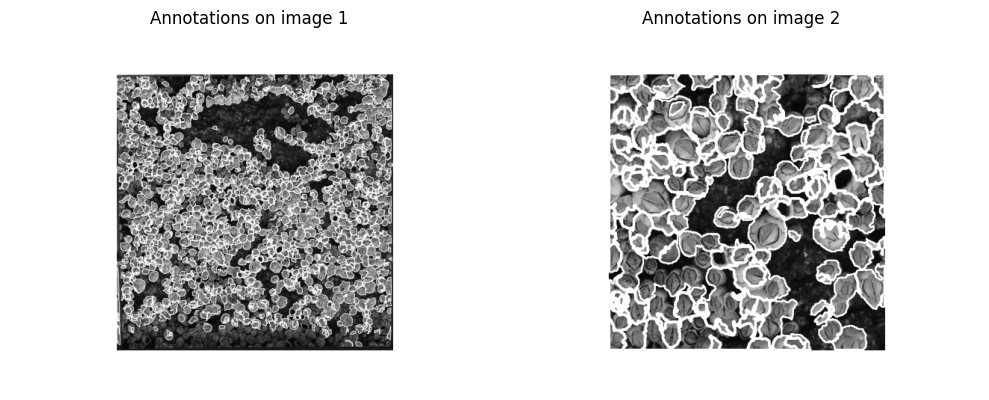

In [579]:
image1 = Image.open("unseen_images/unseen_image_1.png")
image2 = Image.open("unseen_images/unseen_image_2.png")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 10))
axes[0].imshow(image1)
axes[0].set_title("Annotations on image 1")
axes[0].axis("off")

axes[1].imshow(image2)
axes[1].set_title("Annotations on image 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()